In [1]:
 instralpipl seaborn

SyntaxError: invalid syntax (3495040426.py, line 1)

Tổng số ảnh: 2994
Tổng số đối tượng: 31271


C:\Users\vinh\AppData\Local\Temp\ipykernel_12456\1441593496.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, 0].legend()


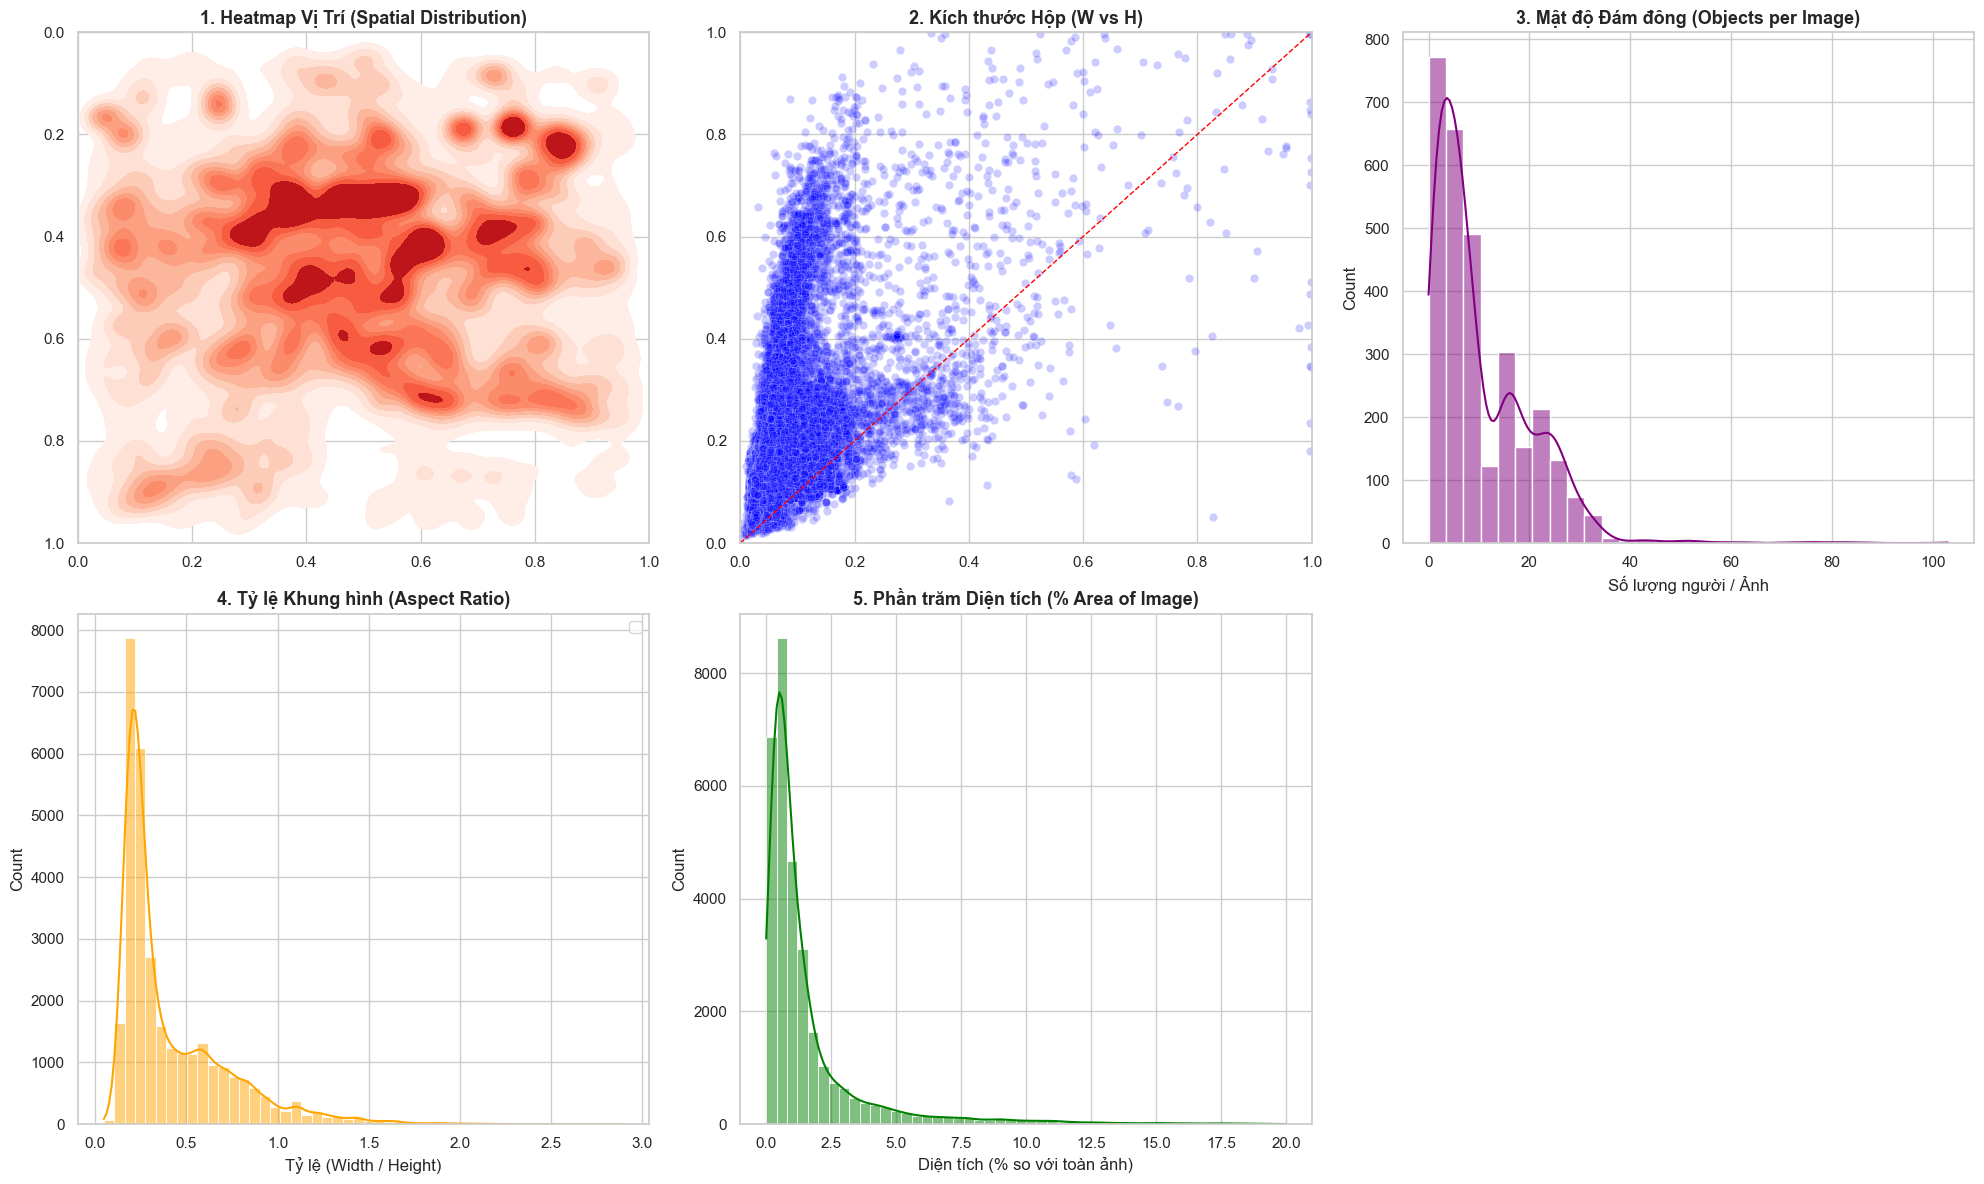

In [14]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. THIẾT LẬP ĐƯỜNG DẪN
label_dir = r"C:\Users\vinh\Desktop\lamdataset\train\labels"
# ==========================================

x_centers, y_centers, widths, heights = [], [], [], []
objects_per_image = [] # Đếm số người trên 1 ảnh
aspect_ratios = []     # Tỷ lệ khung hình (Width / Height)
areas = []             # Diện tích Bounding Box

# 2. ĐỌC DỮ LIỆU
for filename in os.listdir(label_dir):
    if filename.endswith(".txt"):
        with open(os.path.join(label_dir, filename), 'r') as f:
            lines = f.readlines()
            # Đếm số lượng object trong 1 bức ảnh
            objects_per_image.append(len(lines))
            
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    x, y, w, h = map(float, parts[1:5])
                    x_centers.append(x)
                    y_centers.append(y)
                    widths.append(w)
                    heights.append(h)
                    
                    # Tính toán các chỉ số nâng cao
                    if h > 0:
                        aspect_ratios.append(w / h)
                    areas.append(w * h * 100) # Tính % diện tích so với toàn ảnh

print(f"Tổng số ảnh: {len(objects_per_image)}")
print(f"Tổng số đối tượng: {len(widths)}")

# 3. VẼ DASHBOARD (Lưới 2x3)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
sns.set_theme(style="whitegrid")

# [Biểu đồ 1] Heatmap Vị trí (Không gian)
sns.kdeplot(x=x_centers, y=y_centers, cmap="Reds", fill=True, bw_adjust=0.5, ax=axes[0, 0])
axes[0, 0].set_xlim(0, 1); axes[0, 0].set_ylim(1, 0)
axes[0, 0].set_title("1. Heatmap Vị Trí (Spatial Distribution)", fontsize=13, fontweight='bold')

# [Biểu đồ 2] Phân bố Kích thước (Width vs Height)
sns.scatterplot(x=widths, y=heights, alpha=0.2, color="blue", ax=axes[0, 1])
axes[0, 1].set_xlim(0, 1); axes[0, 1].set_ylim(0, 1)
axes[0, 1].plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1) # Đường chéo W=H
axes[0, 1].set_title("2. Kích thước Hộp (W vs H)", fontsize=13, fontweight='bold')

# [Biểu đồ 3] Số lượng đối tượng trên mỗi ảnh (Crowd Density)
sns.histplot(objects_per_image, bins=30, kde=True, color="purple", ax=axes[0, 2])
axes[0, 2].set_title("3. Mật độ Đám đông (Objects per Image)", fontsize=13, fontweight='bold')
axes[0, 2].set_xlabel("Số lượng người / Ảnh")

# [Biểu đồ 4] Tỷ lệ khung hình (Aspect Ratio)
# Cắt bớt các giá trị nhiễu (outliers) để biểu đồ dễ nhìn
filtered_ratios = [r for r in aspect_ratios if 0 < r < 3] 
sns.histplot(filtered_ratios, bins=50, kde=True, color="orange", ax=axes[1, 0])

axes[1, 0].set_title("4. Tỷ lệ Khung hình (Aspect Ratio)", fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel("Tỷ lệ (Width / Height)")
axes[1, 0].legend()

# [Biểu đồ 5] Diện tích Object (Object Area)
# Chỉ hiển thị dưới 20% diện tích ảnh vì đối tượng thường rất nhỏ
filtered_areas = [a for a in areas if a < 20]
sns.histplot(filtered_areas, bins=50, kde=True, color="green", ax=axes[1, 1])
axes[1, 1].set_title("5. Phần trăm Diện tích (% Area of Image)", fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel("Diện tích (% so với toàn ảnh)")

# Biểu đồ 6: Tắt đi để bố cục cân đối
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

In [7]:
pip install albumentations

   ---------------------------------------- 0.0/40.1 MB ? eta -:--:--
   -- ------------------------------------- 2.1/40.1 MB 10.7 MB/s eta 0:00:04
   --- ------------------------------------ 3.4/40.1 MB 10.6 MB/s eta 0:00:04
   ------ --------------------------------- 6.8/40.1 MB 10.8 MB/s eta 0:00:04
   --------- ------------------------------ 9.4/40.1 MB 11.1 MB/s eta 0:00:03
   ----------- ---------------------------- 11.8/40.1 MB 11.2 MB/s eta 0:00:03
   -------------- ------------------------- 14.4/40.1 MB 11.3 MB/s eta 0:00:03
   ---------------- ----------------------- 16.8/40.1 MB 11.5 MB/s eta 0:00:03
   ------------------- -------------------- 19.4/40.1 MB 11.4 MB/s eta 0:00:02
   --------------------- ------------------ 22.0/40.1 MB 11.5 MB/s eta 0:00:02
   ------------------------ --------------- 24.6/40.1 MB 11.6 MB/s eta 0:00:02
   -------------------------- ------------- 27.0/40.1 MB 11.6 MB/s eta 0:00:02
   ----------------------------- ---------- 29.6/40.1 MB 11.6 MB/

In [12]:
import albumentations as A
import cv2
import os
import glob
import numpy as np
import random

# 1. Đường dẫn (Giữ nguyên của bạn)
IMAGE_DIR = r"C:\Users\vinh\Desktop\lamdataset\train\images"
LABEL_DIR = r"C:\Users\vinh\Desktop\lamdataset\train\labels"
SAVE_IMG_DIR = r"C:\Users\vinh\Desktop\datasetcopy\images"
SAVE_LAB_DIR = r"C:\Users\vinh\Desktop\datasetcopy\labels"

os.makedirs(SAVE_IMG_DIR, exist_ok=True)
os.makedirs(SAVE_LAB_DIR, exist_ok=True)

# 2. Định nghĩa 4 chiến thuật riêng biệt
# Cách 1: Zoom mạnh vào đối tượng
transform_zoom = A.Compose([
    A.RandomSizedBBoxSafeCrop(width=640, height=640, erosion_rate=0.3, p=1.0)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# Cách 2: Lật (Trái-Phải và Trên-Dưới)
transform_flip = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# Cách 3: Xoay ngẫu nhiên các góc lớn (để người rải đều các góc)
transform_rotate = A.Compose([
    A.RandomRotate90(p=1.0), # Xoay 90, 180, 270 độ
    A.Rotate(limit=20, p=0.5) # Xoay nhẹ thêm để đa dạng
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# Cách 4: Kéo/Dịch chuyển (Translate) để thay đổi vị trí heatmap
transform_shift = A.Compose([
    A.ShiftScaleRotate(shift_limit=0.2, scale_limit=0, rotate_limit=0, p=1.0)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 3. Quá trình xử lý
image_files = glob.glob(os.path.join(IMAGE_DIR, "*.jpg"))

for img_path in image_files:
    file_name = os.path.basename(img_path)
    name_wo_ext = os.path.splitext(file_name)[0]
    
    image = cv2.imread(img_path)
    if image is None: continue
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    label_path = os.path.join(LABEL_DIR, name_wo_ext + ".txt")
    if not os.path.exists(label_path): continue
        
    bboxes, class_labels = [], []
    with open(label_path, 'r') as f:
        for line in f.readlines():
            parts = line.split()
            if len(parts) < 5: continue
            class_labels.append(int(parts[0]))
            bboxes.append([float(x) for x in parts[1:]])

    # RANDOM CHỌN 1 TRONG 4 CÁCH
    choice = random.choice([transform_zoom, transform_flip, transform_rotate, transform_shift])
    
    try:
        transformed = choice(image=image, bboxes=bboxes, class_labels=class_labels)
        t_image = transformed['image']
        t_bboxes = transformed['bboxes']
        t_classes = transformed['class_labels']

        if len(t_bboxes) > 0:
            # Lưu ảnh
            new_name = f"aug_rand_{file_name}"
            cv2.imwrite(os.path.join(SAVE_IMG_DIR, new_name), 
                        cv2.cvtColor(t_image, cv2.COLOR_RGB2BGR))
            
            # Lưu nhãn
            with open(os.path.join(SAVE_LAB_DIR, f"aug_rand_{name_wo_ext}.txt"), 'w') as f:
                for cls, box in zip(t_classes, t_bboxes):
                    box = [max(min(x, 1.0), 0.0) for x in box]
                    f.write(f"{cls} {' '.join(map(str, box))}\n")
    except Exception as e:
        print(f"Lỗi {file_name}: {e}")

print("Xong! Data đã được xáo trộn ngẫu nhiên.")


c:\Users\vinh\anaconda3\envs\ml-python311\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Lỗi 92773702-view-from-the-top-business-team-standing-in-a-row_jpg.rf.c584fa6a41af0e2659015fe18b6db168.jpg: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (5,) + inhomogeneous part.
Lỗi ExternDisk_ch1_20250819071100_20250819071900_f0013325_jpg.rf.a8a8b17ead18959b9168035e5934c6aa.jpg: Expected x_min for bbox [-7.8156590e-06  3.1842187e-01  1.7438281e-01  6.0214067e-01
  0.0000000e+00] to be in the range [0.0, 1.0], got -7.815659046173096e-06.
Lỗi ExternDisk_ch1_20250819072700_20250819073500_f0001069_jpg.rf.fe9144350050f5855a4fcd7597a34465.jpg: Expected x_min for bbox [-7.8082085e-06  2.3471874e-01  2.4135156e-01  4.3056250e-01
  0.0000000e+00] to be in the range [0.0, 1.0], got -7.808208465576172e-06.
Lỗi ExternDisk_ch1_20250819073500_20250819074300_f0005651-copia-copia_jpg.rf.a76073be45bf6b68773147b997e67170.jpg: Expected x_min for bbox [-7.8082085e-06  5.6731248e-01  3.1110156e-01  7.6815629e-01
  0.0

Tổng số ảnh: 6084
Tổng số đối tượng: 62757


C:\Users\vinh\AppData\Local\Temp\ipykernel_12456\3323173867.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, 0].legend()


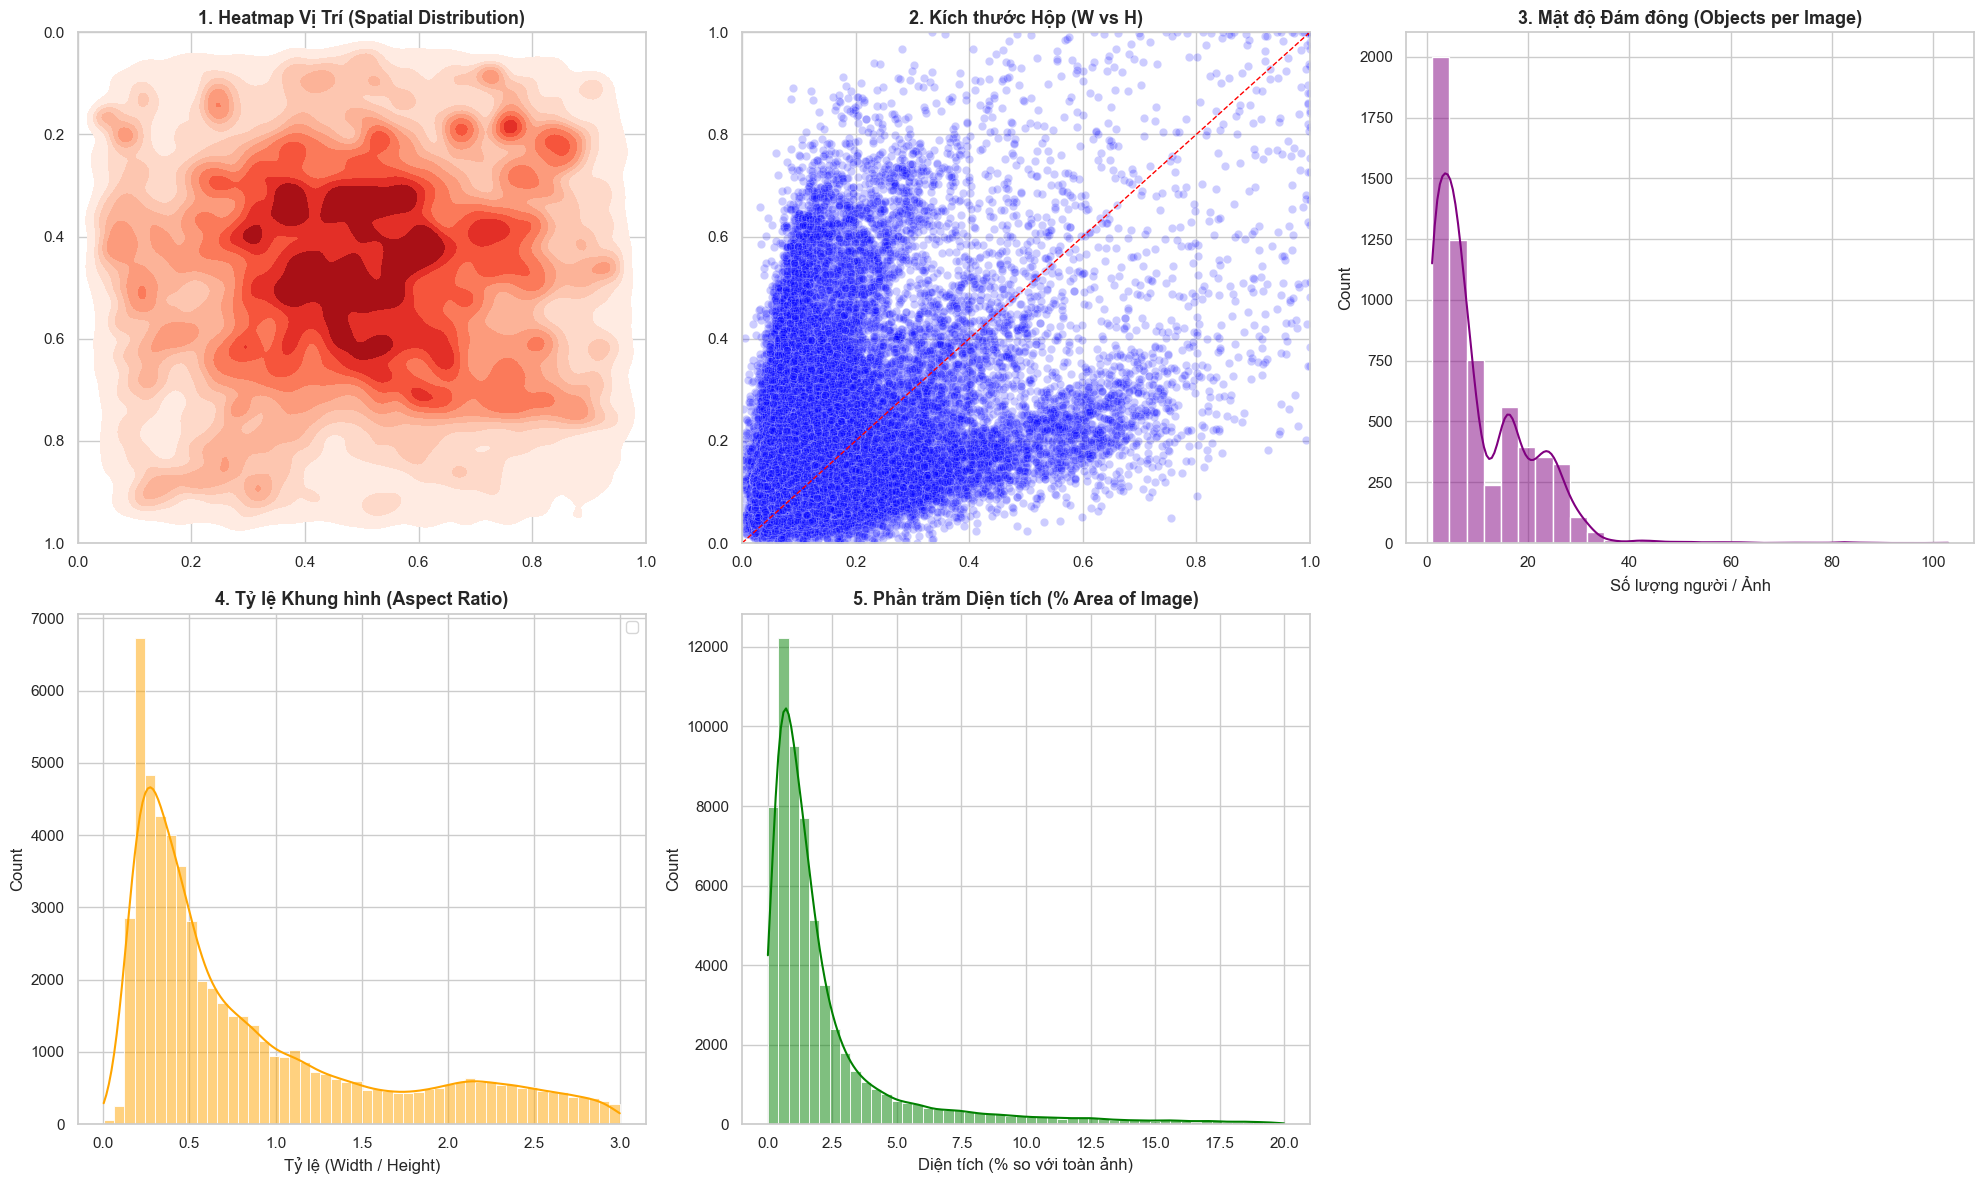

In [21]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. THIẾT LẬP ĐƯỜNG DẪN
label_dir = r"C:\Users\vinh\Desktop\datasetcopy\train\labels"
# ==========================================

x_centers, y_centers, widths, heights = [], [], [], []
objects_per_image = [] # Đếm số người trên 1 ảnh
aspect_ratios = []     # Tỷ lệ khung hình (Width / Height)
areas = []             # Diện tích Bounding Box

# 2. ĐỌC DỮ LIỆU
for filename in os.listdir(label_dir):
    if filename.endswith(".txt"):
        with open(os.path.join(label_dir, filename), 'r') as f:
            lines = f.readlines()
            # Đếm số lượng object trong 1 bức ảnh
            objects_per_image.append(len(lines))
            
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    x, y, w, h = map(float, parts[1:5])
                    x_centers.append(x)
                    y_centers.append(y)
                    widths.append(w)
                    heights.append(h)
                    
                    # Tính toán các chỉ số nâng cao
                    if h > 0:
                        aspect_ratios.append(w / h)
                    areas.append(w * h * 100) # Tính % diện tích so với toàn ảnh

print(f"Tổng số ảnh: {len(objects_per_image)}")
print(f"Tổng số đối tượng: {len(widths)}")

# 3. VẼ DASHBOARD (Lưới 2x3)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
sns.set_theme(style="whitegrid")

# [Biểu đồ 1] Heatmap Vị trí (Không gian)
sns.kdeplot(x=x_centers, y=y_centers, cmap="Reds", fill=True, bw_adjust=0.5, ax=axes[0, 0])
axes[0, 0].set_xlim(0, 1); axes[0, 0].set_ylim(1, 0)
axes[0, 0].set_title("1. Heatmap Vị Trí (Spatial Distribution)", fontsize=13, fontweight='bold')

# [Biểu đồ 2] Phân bố Kích thước (Width vs Height)
sns.scatterplot(x=widths, y=heights, alpha=0.2, color="blue", ax=axes[0, 1])
axes[0, 1].set_xlim(0, 1); axes[0, 1].set_ylim(0, 1)
axes[0, 1].plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1) # Đường chéo W=H
axes[0, 1].set_title("2. Kích thước Hộp (W vs H)", fontsize=13, fontweight='bold')

# [Biểu đồ 3] Số lượng đối tượng trên mỗi ảnh (Crowd Density)
sns.histplot(objects_per_image, bins=30, kde=True, color="purple", ax=axes[0, 2])
axes[0, 2].set_title("3. Mật độ Đám đông (Objects per Image)", fontsize=13, fontweight='bold')
axes[0, 2].set_xlabel("Số lượng người / Ảnh")

# [Biểu đồ 4] Tỷ lệ khung hình (Aspect Ratio)
# Cắt bớt các giá trị nhiễu (outliers) để biểu đồ dễ nhìn
filtered_ratios = [r for r in aspect_ratios if 0 < r < 3] 
sns.histplot(filtered_ratios, bins=50, kde=True, color="orange", ax=axes[1, 0])

axes[1, 0].set_title("4. Tỷ lệ Khung hình (Aspect Ratio)", fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel("Tỷ lệ (Width / Height)")
axes[1, 0].legend()

# [Biểu đồ 5] Diện tích Object (Object Area)
# Chỉ hiển thị dưới 20% diện tích ảnh vì đối tượng thường rất nhỏ
filtered_areas = [a for a in areas if a < 20]
sns.histplot(filtered_areas, bins=50, kde=True, color="green", ax=axes[1, 1])
axes[1, 1].set_title("5. Phần trăm Diện tích (% Area of Image)", fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel("Diện tích (% so với toàn ảnh)")

# Biểu đồ 6: Tắt đi để bố cục cân đối
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

Tổng số ảnh: 5784
Tổng số đối tượng: 60760


C:\Users\vinh\AppData\Local\Temp\ipykernel_12456\2082168688.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, 0].legend()


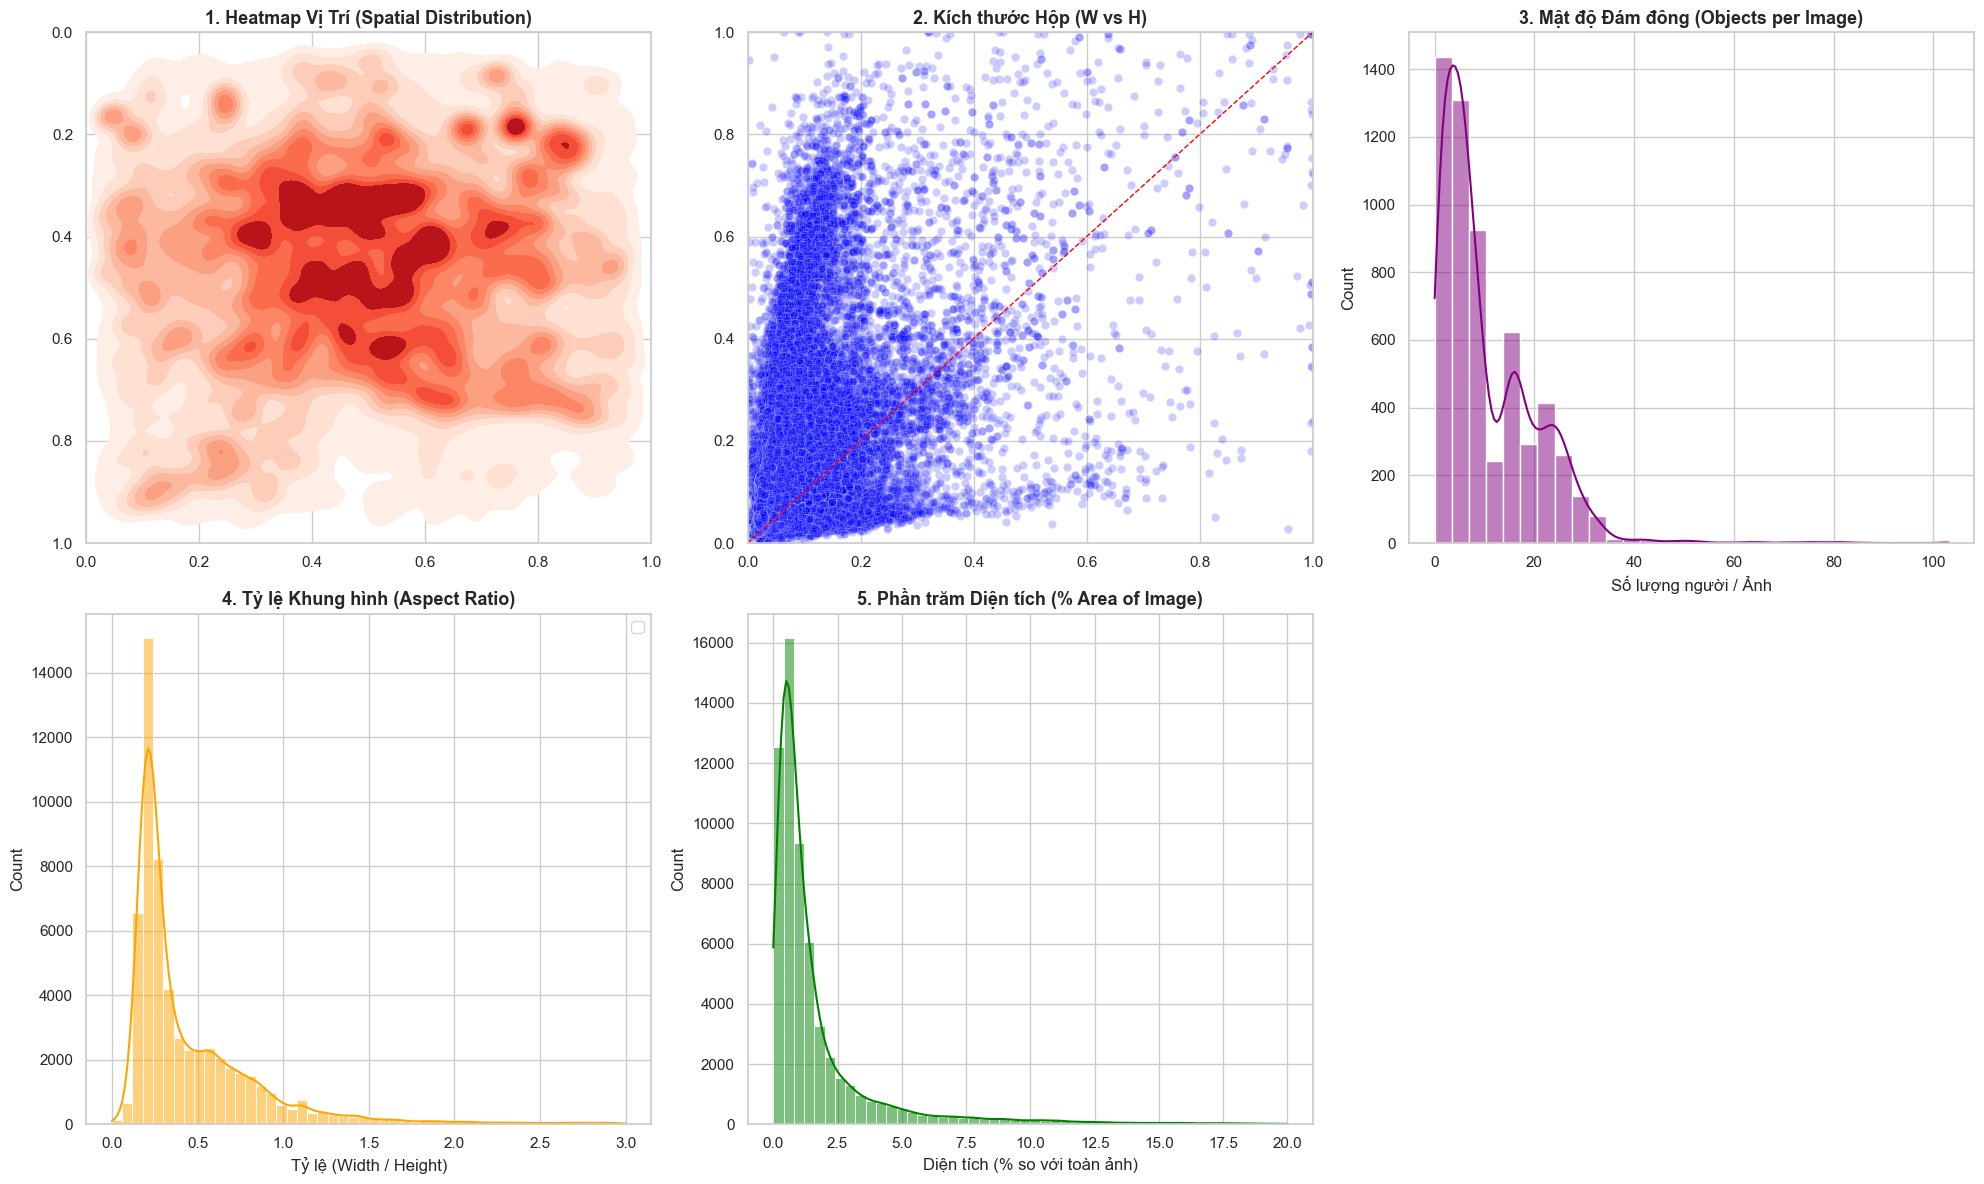

In [15]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. THIẾT LẬP ĐƯỜNG DẪN
label_dir = r"C:\Users\vinh\Desktop\datasetpro\train\labels"
# ==========================================

x_centers, y_centers, widths, heights = [], [], [], []
objects_per_image = [] # Đếm số người trên 1 ảnh
aspect_ratios = []     # Tỷ lệ khung hình (Width / Height)
areas = []             # Diện tích Bounding Box

# 2. ĐỌC DỮ LIỆU
for filename in os.listdir(label_dir):
    if filename.endswith(".txt"):
        with open(os.path.join(label_dir, filename), 'r') as f:
            lines = f.readlines()
            # Đếm số lượng object trong 1 bức ảnh
            objects_per_image.append(len(lines))
            
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    x, y, w, h = map(float, parts[1:5])
                    x_centers.append(x)
                    y_centers.append(y)
                    widths.append(w)
                    heights.append(h)
                    
                    # Tính toán các chỉ số nâng cao
                    if h > 0:
                        aspect_ratios.append(w / h)
                    areas.append(w * h * 100) # Tính % diện tích so với toàn ảnh

print(f"Tổng số ảnh: {len(objects_per_image)}")
print(f"Tổng số đối tượng: {len(widths)}")

# 3. VẼ DASHBOARD (Lưới 2x3)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
sns.set_theme(style="whitegrid")

# [Biểu đồ 1] Heatmap Vị trí (Không gian)
sns.kdeplot(x=x_centers, y=y_centers, cmap="Reds", fill=True, bw_adjust=0.5, ax=axes[0, 0])
axes[0, 0].set_xlim(0, 1); axes[0, 0].set_ylim(1, 0)
axes[0, 0].set_title("1. Heatmap Vị Trí (Spatial Distribution)", fontsize=13, fontweight='bold')

# [Biểu đồ 2] Phân bố Kích thước (Width vs Height)
sns.scatterplot(x=widths, y=heights, alpha=0.2, color="blue", ax=axes[0, 1])
axes[0, 1].set_xlim(0, 1); axes[0, 1].set_ylim(0, 1)
axes[0, 1].plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1) # Đường chéo W=H
axes[0, 1].set_title("2. Kích thước Hộp (W vs H)", fontsize=13, fontweight='bold')

# [Biểu đồ 3] Số lượng đối tượng trên mỗi ảnh (Crowd Density)
sns.histplot(objects_per_image, bins=30, kde=True, color="purple", ax=axes[0, 2])
axes[0, 2].set_title("3. Mật độ Đám đông (Objects per Image)", fontsize=13, fontweight='bold')
axes[0, 2].set_xlabel("Số lượng người / Ảnh")

# [Biểu đồ 4] Tỷ lệ khung hình (Aspect Ratio)
# Cắt bớt các giá trị nhiễu (outliers) để biểu đồ dễ nhìn
filtered_ratios = [r for r in aspect_ratios if 0 < r < 3] 
sns.histplot(filtered_ratios, bins=50, kde=True, color="orange", ax=axes[1, 0])

axes[1, 0].set_title("4. Tỷ lệ Khung hình (Aspect Ratio)", fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel("Tỷ lệ (Width / Height)")
axes[1, 0].legend()

# [Biểu đồ 5] Diện tích Object (Object Area)
# Chỉ hiển thị dưới 20% diện tích ảnh vì đối tượng thường rất nhỏ
filtered_areas = [a for a in areas if a < 20]
sns.histplot(filtered_areas, bins=50, kde=True, color="green", ax=axes[1, 1])
axes[1, 1].set_title("5. Phần trăm Diện tích (% Area of Image)", fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel("Diện tích (% so với toàn ảnh)")

# Biểu đồ 6: Tắt đi để bố cục cân đối
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import albumentations as A
import cv2
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# 1. Cấu hình
IMAGE_DIR = r"C:\Users\vinh\Desktop\lamdataset\train\images"
LABEL_DIR = r"C:\Users\vinh\Desktop\lamdataset\train\labels"
SAVE_DIR = r"C:\Users\vinh\Desktop\dataset_fix"

os.makedirs(os.path.join(SAVE_DIR, "images"), exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, "labels"), exist_ok=True)


def stretch_image_with_keypoints(image, keypoints, width_factor=1.5, height_factor=1.0):
    height, width = image.shape[:2]
    new_w = int(width * width_factor)
    new_h = int(height * height_factor)
    
    transform = A.Compose([
        # Thay đổi kích thước ảnh về tỉ lệ mong muốn
        A.Resize(height=new_h, width=new_w, p=1.0)
    ], keypoint_params=A.KeypointParams(format='xy'))

    transformed = transform(image=image, keypoints=keypoints)
    return transformed['IMAGE_DIR'], transformed['LABEL_DIR']